In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")   # themes: white, dark, ticks
sns.set_palette("deep")      # color themes

Loading the Dataset

In [7]:
df=pd.read_csv('House Price India.csv')
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14620 entries, 0 to 14619
Data columns (total 23 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     14620 non-null  int64  
 1   Date                                   14620 non-null  int64  
 2   number of bedrooms                     14620 non-null  int64  
 3   number of bathrooms                    14620 non-null  float64
 4   living area                            14620 non-null  int64  
 5   lot area                               14620 non-null  int64  
 6   number of floors                       14620 non-null  float64
 7   waterfront present                     14620 non-null  int64  
 8   number of views                        14620 non-null  int64  
 9   condition of the house                 14620 non-null  int64  
 10  grade of the house                     14620 non-null  int64  
 11  Ar

Checking for Nulls

In [8]:
df.isnull().sum()

id                                       0
Date                                     0
number of bedrooms                       0
number of bathrooms                      0
living area                              0
lot area                                 0
number of floors                         0
waterfront present                       0
number of views                          0
condition of the house                   0
grade of the house                       0
Area of the house(excluding basement)    0
Area of the basement                     0
Built Year                               0
Renovation Year                          0
Postal Code                              0
Lattitude                                0
Longitude                                0
living_area_renov                        0
lot_area_renov                           0
Number of schools nearby                 0
Distance from the airport                0
Price                                    0
dtype: int6

In [19]:
df.sample(5)

,number of bedrooms,number of bathrooms,living area,lot area,number of floors,waterfront present,number of views,condition of the house,grade of the house,Area of the house(excluding basement),...,Built Year,Renovation Year,Postal Code,Lattitude,Longitude,living_area_renov,lot_area_renov,Number of schools nearby,Distance from the airport,Price
6406,3,1.50,1190,20672,1.5,0,3,3,7,1190,...,1948,0,122031,52.6759,-114.549,2150,16239,2,76,375000
3472,5,2.50,2360,11375,1.0,0,0,4,7,1180,...,1962,0,122063,52.7175,-114.445,1160,7800,1,66,317000
3302,3,1.75,1300,12731,1.0,0,0,3,8,1300,...,1981,0,122019,52.8536,-114.230,1700,13556,3,73,430000
1435,3,2.50,2810,7700,2.0,0,0,3,9,2810,...,2001,0,122027,52.7764,-114.381,2910,8250,2,69,685000
544,4,1.75,2120,4650,1.0,0,1,3,7,1190,...,1951,0,122007,52.9264,-114.590,2070,6487,2,70,582000


In [13]:
df['Distance from the airport'].unique()

array([58, 51, 53, 76, 67, 72, 71, 73, 69, 80, 74, 55, 70, 75, 60, 50, 64,
       66, 79, 78, 61, 52, 68, 62, 63, 77, 56, 65, 57, 59, 54])

Drop Unwanted Columns

In [14]:
df.drop(['id'],axis=1,inplace=True)

In [18]:
df=df.drop(['Date'],axis=1)

Understanding Correlation of each Column with Target Column

In [29]:
df.corr(numeric_only=True)['Price'].sort_values()*100

Distance from the airport                  0.380370
Number of schools nearby                   0.988989
Longitude                                  2.441402
condition of the house                     4.137638
Built Year                                 5.030711
lot_area_renov                             7.553517
lot area                                   8.199200
Renovation Year                           13.317265
number of floors                          26.273183
waterfront present                        26.368655
Lattitude                                 29.748998
number of bedrooms                        30.846014
Area of the basement                      33.020233
number of views                           39.597310
number of bathrooms                       53.173456
living_area_renov                         58.492446
Area of the house(excluding basement)     61.522042
grade of the house                        67.181438
living area                               71.216948
Price       

Converting Postal Codes to String 

In [28]:
df['Postal Code']=df['Postal Code'].astype(str)

Understanding Correlation between Each Feature Columns

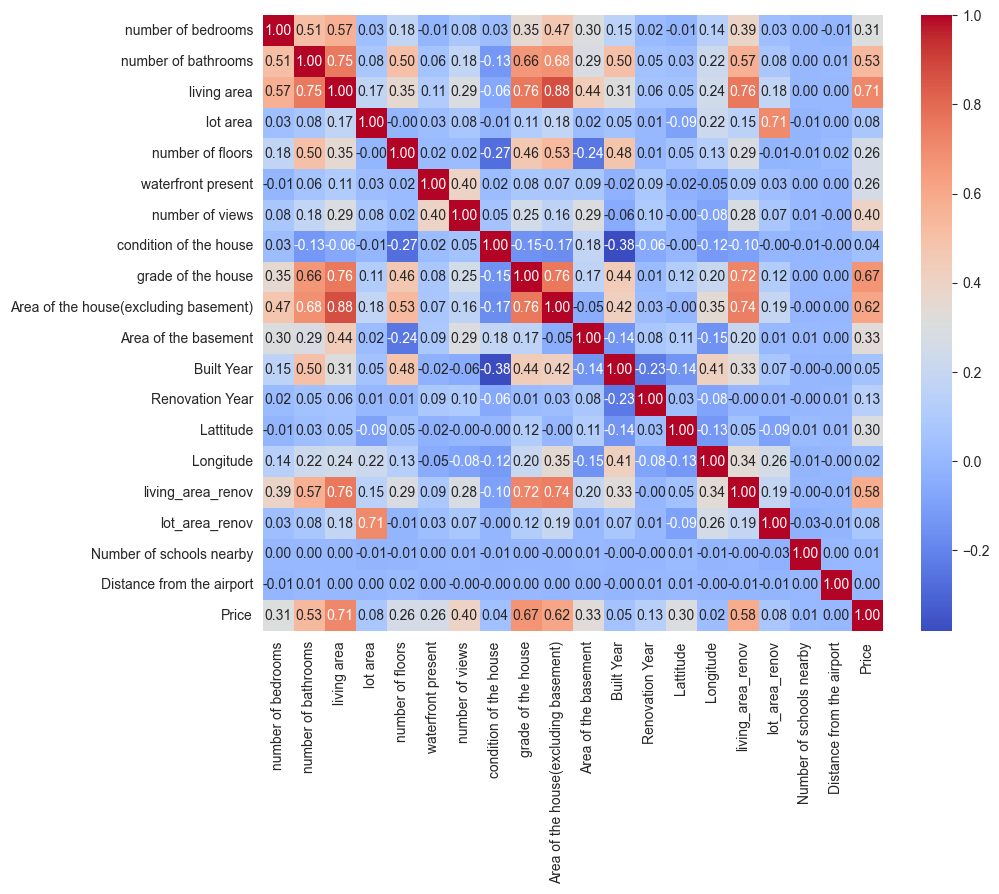

In [56]:
plt.figure(figsize=(10,8))

corr=df.corr(numeric_only=True)

sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')
plt.show()

EDA for better understanding 

After anlyzing this we realized it is right skewed So we will Apply log transformation during Model Training


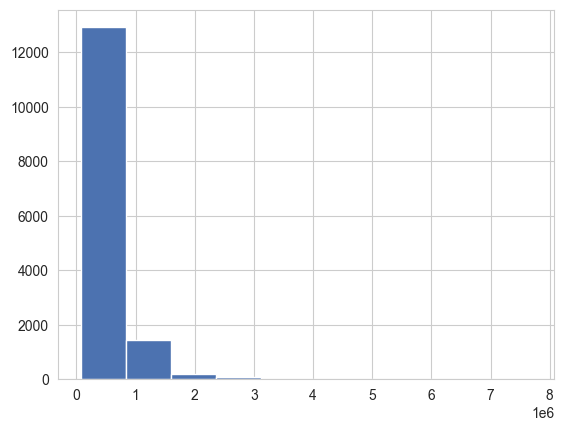

In [57]:
df['Price'].hist()
print("After anlyzing this we realized it is right skewed So we will Apply log transformation during Model Training")

<Axes: xlabel='living area', ylabel='Price'>

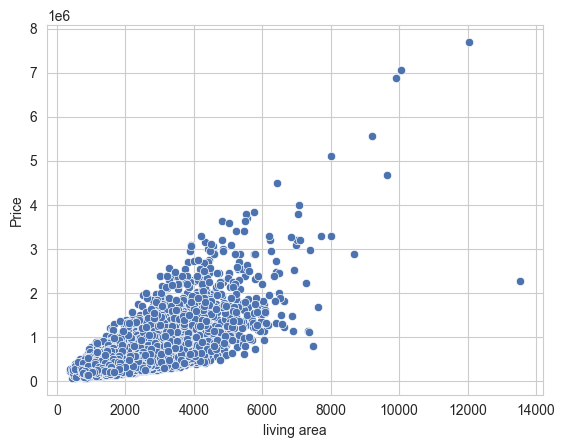

In [63]:
sns.scatterplot(data=df,x='living area',y='Price')

<Axes: xlabel='Distance from the airport', ylabel='Price'>

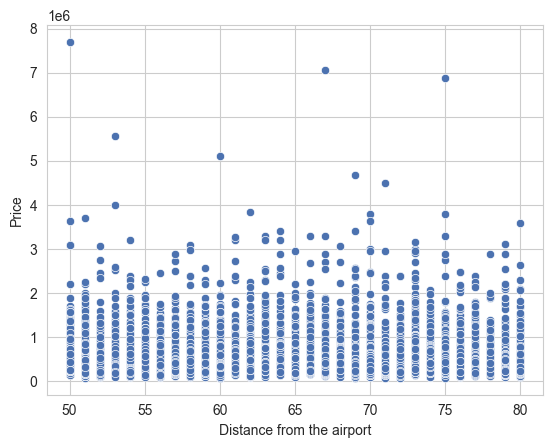

In [65]:
sns.scatterplot(data=df,x='Distance from the airport',y='Price')